In [1]:
# Gas Turbine Energy Yield Prediction using Neural Networks

Objective:
To predict Turbine Energy Yield (TEY)
using ambient and sensor variables
through Artificial Neural Networks.

In [4]:
# Run this only if TensorFlow is not installed

!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
    --------------------------------------- 5.5/351.2 MB 26.5 MB/s eta 0:00:14
   - -------------------------------------- 12.6/351.2 MB 30.5 MB/s eta 0:00:12
   - -------------------------------------- 14.4/351.2 MB 22.8 MB/s eta 0:00:15
   -- ------------------------------------- 21.2/351.2 MB 25.0 MB/s eta 0:00:14
   --- ------------------------------------ 27.5/351.2 MB 25.8 MB/s eta 0:00:13
   --- ------------------------------------ 33.3/351.2 MB 26.4 MB/s eta 0:00:13
   ---- ----------------------------------- 36.2/351.2 MB 24.9 MB/s eta 0:00:13
   ---- ----------------------------------- 38.3/351.2 MB 22.6 MB/s eta 0:00:14
   ---- ----------------------------------- 40.6/351.2 MB 21.4 MB/s eta 0:00:15
   ----- ---------------------------------- 44.3/351.2 MB 20.9 MB/s eta 0:00:15
   ----- ---------------------------------- 47.7/351.2 MB 20.7 MB/s eta 0:00:15
   ----- ---------------------------------- 52.2/3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [8]:
# Import Libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import mean_squared_error, r2_score

In [6]:
# Load dataset
df = pd.read_csv("D:/Goutham/Projects/Python/Project 7/Neural Network - Assignment 7/gas_turbines.csv")

df.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,6.8594,1007.9,96.799,3.5000,19.663,1059.2,550.00,114.70,10.605,3.1547,82.722
1,6.7850,1008.4,97.118,3.4998,19.728,1059.3,550.00,114.72,10.598,3.2363,82.776
2,6.8977,1008.8,95.939,3.4824,19.779,1059.4,549.87,114.71,10.601,3.2012,82.468
3,7.0569,1009.2,95.249,3.4805,19.792,1059.6,549.99,114.72,10.606,3.1923,82.670
4,7.3978,1009.7,95.150,3.4976,19.765,1059.7,549.98,114.72,10.612,3.2484,82.311


In [7]:
# Understanding the data
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15039 entries, 0 to 15038
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      15039 non-null  float64
 1   AP      15039 non-null  float64
 2   AH      15039 non-null  float64
 3   AFDP    15039 non-null  float64
 4   GTEP    15039 non-null  float64
 5   TIT     15039 non-null  float64
 6   TAT     15039 non-null  float64
 7   TEY     15039 non-null  float64
 8   CDP     15039 non-null  float64
 9   CO      15039 non-null  float64
 10  NOX     15039 non-null  float64
dtypes: float64(11)
memory usage: 1.3 MB


(15039, 11)

In [9]:
# Checking missing value
df.isnull().sum()

AT      0
AP      0
AH      0
AFDP    0
GTEP    0
TIT     0
TAT     0
TEY     0
CDP     0
CO      0
NOX     0
dtype: int64

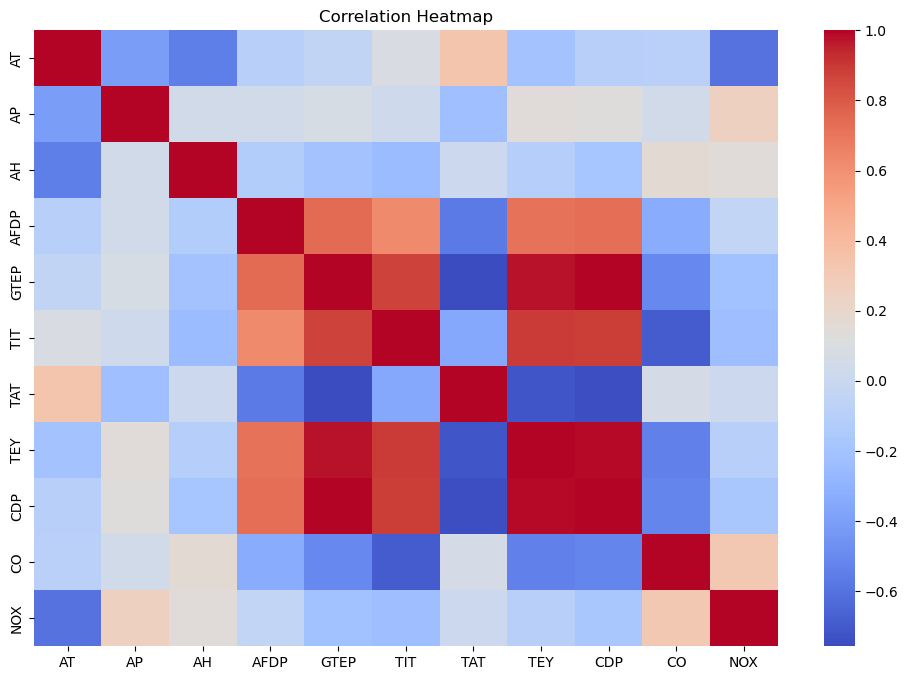

In [10]:
# Exploratory Data Analysis

# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

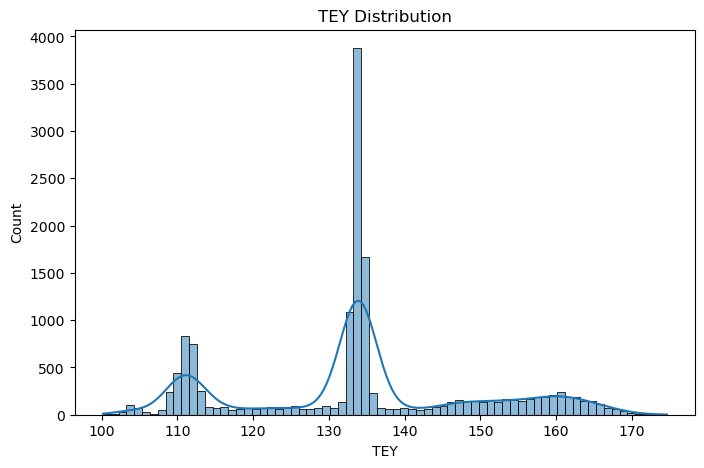

In [11]:
# TEY Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['TEY'],
    kde=True
)

plt.title("TEY Distribution")

plt.show()

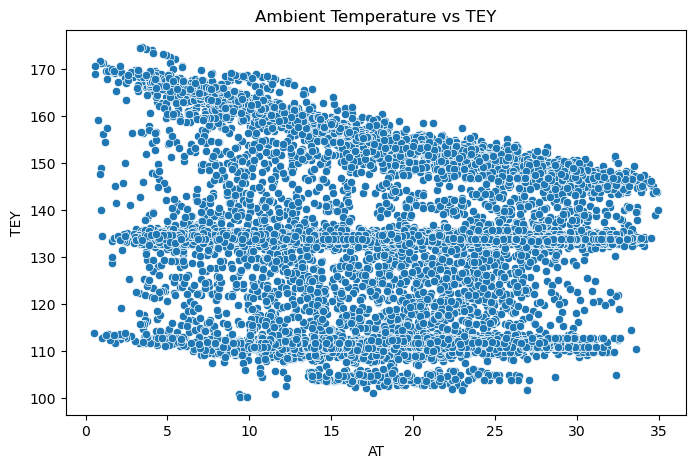

In [12]:
# Ambient Temperature vs TEY
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['AT'],
    y=df['TEY']
)

plt.title("Ambient Temperature vs TEY")

plt.show()

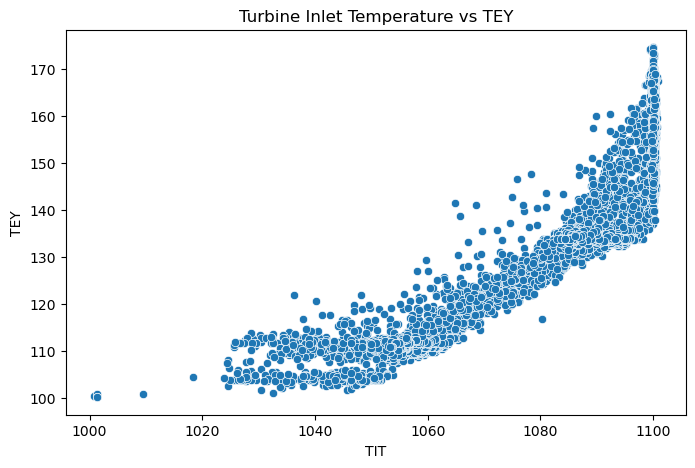

In [13]:
# TIT vs TEY
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['TIT'],
    y=df['TEY']
)

plt.title("Turbine Inlet Temperature vs TEY")

plt.show()

EDA Insights:

- Turbine Energy Yield varies significantly across observations.
- Sensor variables show strong relationships with TEY.
- Temperature and pressure variables influence energy generation.
- The dataset is suitable for regression modeling.

In [14]:
# Define X and y
X = df.drop('TEY', axis=1)

y = df['TEY']

In [15]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Feature scaling is important for Neural Networks because
deep learning models are sensitive to feature magnitudes.

In [17]:
# Building Neural Network Model
model = Sequential()

In [18]:
# Input and Hidden Layer 1
model.add(
    Dense(
        12,
        input_dim=X_train.shape[1],
        activation='relu'
    )
)

C:\Users\scare\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# Hidden Layer 2
model.add(
    Dense(
        8,
        activation='relu'
    )
)

In [20]:
# Output Layer
model.add(
    Dense(
        1,
        activation='linear'
    )
)

In [21]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 12)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 245 (980.00 B)

 Trainable params: 245 (980.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='mse'
)

In [23]:
# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 17346.4609 - val_loss: 15123.9355
Epoch 2/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 9780.1260 - val_loss: 3788.5703
Epoch 3/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1377.4939 - val_loss: 541.0865
Epoch 4/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 395.7304 - val_loss: 312.9160
Epoch 5/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 261.4411 - val_loss: 228.9995
Epoch 6/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 199.5049 - val_loss: 180.5163
Epoch 7/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 158.3205 - val_loss: 146.5592
Epoch 8/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 128.5489 - val_loss: 122.8405
Epoch 9/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 106.7223 - val_loss: 103.2204
Epoch 10/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 89.4913 - val_loss: 88.2299
Epoch 11/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 75.2988 - val_loss: 74

In [24]:
# Predictions
y_pred = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   


In [25]:
# R2 Score
r2_score(y_test, y_pred)

0.9980854294745405

In [26]:
# Root Mean Square Error
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

rmse

np.float64(0.6923789294680925)

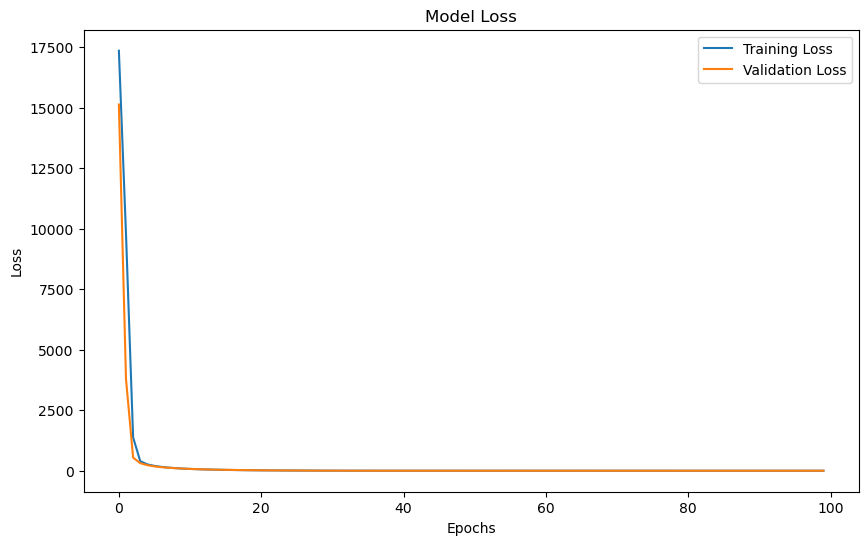

In [27]:
# Loss Curve
plt.figure(figsize=(10,6))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

The loss curve shows how the Neural Network improve.
during training.

Decreasing loss indicates better learning performance.

Artificial Neural Networks (ANN) are deep learning models
inspired by the structure of the human brain.

ANNs are capable of learning complex non-linear relationships
between input variables and target outputs.

Business Insights:

- Turbine sensor variables strongly influence energy yield.
- Neural Networks effectively capture complex industrial patterns.
- Predictive modeling can improve energy optimization.

Business Impact:
- Supports power plant efficiency improvement
- Enables predictive industrial analytics
- Helps optimize turbine performance
- Assists energy management systems

# Final Conclusion:

An Artificial Neural Network model was successfully developed
to predict Turbine Energy Yield (TEY).

The model learned complex relationships between ambient conditions,
sensor variables, and turbine performance.

The project demonstrates how deep learning techniques
can support industrial analytics, energy optimization,
and predictive performance modeling.